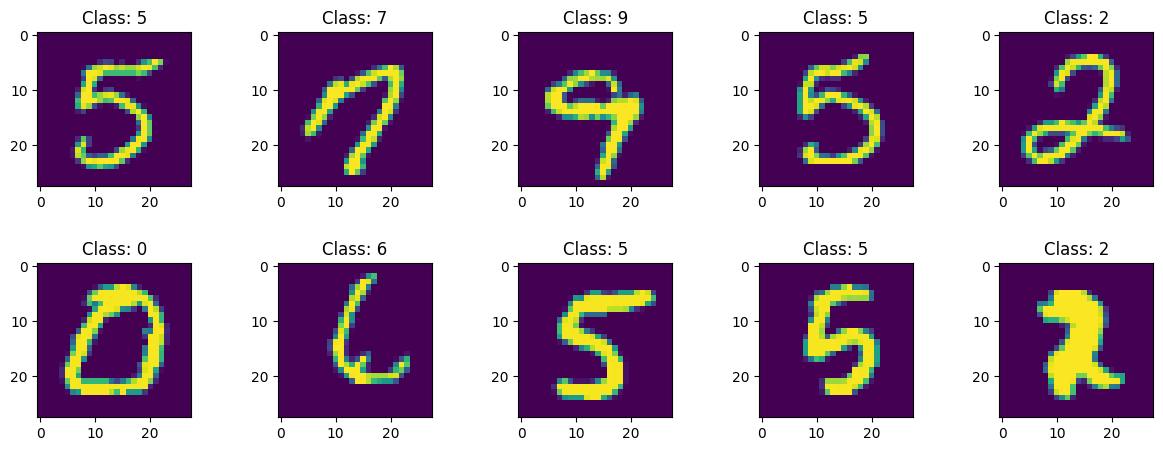

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 24s 134ms/step - accuracy: 0.8461 - loss: 0.5787 - val_accuracy: 0.9370 - val_loss: 0.2113
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 16s 103ms/step - accuracy: 0.9546 - loss: 0.1474 - val_accuracy: 0.9620 - val_loss: 0.1261
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 103ms/step - accuracy: 0.9716 - loss: 0.0968 - val_accuracy: 0.9695 - val_loss: 0.0978
Epoch 4/15
 70/141 ━━━━━━━━━━━━━━━━━━━━ 5s 84ms/step - accuracy: 0.9752 - loss: 0.0747

In [ ]:
# 2.1. Nạp thư viện
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input
import matplotlib.pyplot as plt

# 2.2. Đọc dữ liệu MNIST
mnist_train = '/content/sample_data/mnist_train_small.csv'
mnist_test = '/content/sample_data/mnist_test.csv'
df_train = pd.read_csv(mnist_train)
df_test = pd.read_csv(mnist_test)

X_train = df_train.iloc[:,1:]
y_train = df_train.iloc[:,0]
X_test = df_test.iloc[:,1:]
y_test = df_test.iloc[:,0]

num_classes = 10
input_shape = (28, 28, 1)

# Chuẩn hóa dữ liệu
X_train = X_train.astype("float32")/255
X_test = X_test.astype("float32")/255

# Reshape dữ liệu cho CNN
X_train = X_train.to_numpy().reshape(X_train.shape[0], 28, 28, 1)
X_test = X_test.to_numpy().reshape(X_test.shape[0], 28, 28, 1)

# 2.3. Trực quan hóa 10 ảnh đầu tiên
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15,5))
ax = axes.ravel()
for i in range(10):
    ax[i].imshow(X_train[i].reshape(28, 28))
    ax[i].title.set_text('Class: ' + str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

# 2.4. Chuyển giá trị nhãn thành one-hot encoding
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

# 2.5. Xây dựng mô hình CNN
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))
model.summary()

# 2.6. Huấn luyện mô hình CNN
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_fit = model.fit(X_train, y_train, batch_size=128, epochs=15, validation_split=0.1, verbose=1)

# 2.7. Đánh giá mô hình CNN (Đồ thị accuracy và loss)
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

# 2.8. Đánh giá mô hình trên tập test
score = model.evaluate(X_test, y_test, verbose=2)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

# 2.9. Dự báo nhãn cho ảnh sử dụng CNN
predict = model.predict(X_test[:1])
print(predict)
print("Dự đoán:", np.argmax(predict), "Thực tế:", np.argmax(y_test[0]))
plt.imshow(X_test[0].reshape(28, 28))
plt.show()

# 2.10. Lưu tham số mô hình CNN
model.save_weights('cnn.weights.h5')

# 2.11. Nạp lại mô hình và dự báo thử nghiệm
model_reloaded = Sequential()
model_reloaded.add(Input(shape=input_shape))
model_reloaded.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model_reloaded.add(MaxPool2D(pool_size=(2,2)))
model_reloaded.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model_reloaded.add(MaxPool2D(pool_size=(2,2)))
model_reloaded.add(Flatten())
model_reloaded.add(Dense(units=10, activation='softmax'))
model_reloaded.load_weights('cnn.weights.h5')

# Dự báo sau khi nạp lại
predict_new = model_reloaded.predict(X_test[1:2])
print("Dự đoán mới:", np.argmax(predict_new), "Thực tế:", np.argmax(y_test[1]))
plt.imshow(X_test[1].reshape(28, 28))
plt.show()

1.  chương trình cài đặt CNN để nhận dạng ảnh trên bộ dataset CIFAR10 có sẵn trong tensorflow với các nhãn sau

In [ ]:
# 1. Nạp thư viện
import numpy as np
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, Input
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# 2. Đọc và chuẩn hóa dữ liệu
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()
X_train, X_test = X_train.astype("float32") / 255.0, X_test.astype("float32") / 255.0
y_train, y_test = keras.utils.to_categorical(y_train, 10), keras.utils.to_categorical(y_test, 10)

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# 3. Xây dựng mô hình
model = Sequential([
    Input(shape=(32, 32, 3)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPool2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPool2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPool2D((2, 2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5), # Chống overfitting
    Dense(10, activation='softmax')
])

# 4. Biên dịch và Huấn luyện với EarlyStopping
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Tự động dừng khi val_loss không giảm sau 3 epochs
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    batch_size=128, epochs=10,
    validation_split=0.1,
    callbacks=[es],
    verbose=1
)

# 5. Đánh giá và lưu model
score = model.evaluate(X_test, y_test, verbose=2)
print(f"Test Accuracy: {score[1]*100:.2f}%")
model.save_weights('cifar10_cnn_optimized.weights.h5')

# 6. Dự đoán và hiển thị kết quả
predict = model.predict(X_test[1:2])
predicted_label = class_names[np.argmax(predict)]
actual_label = class_names[np.argmax(y_test[1])]

plt.imshow(X_test[1])
plt.title(f"Dự đoán: {predicted_label} | Thực tế: {actual_label}")
plt.axis('off')
plt.show()

2.  viết chương trình cài đặt CNN để nhận dạng ảnh Cat hoặc Dog.

In [ ]:
# 1. Nạp thư viện
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# 2. Tự động lấy dữ liệu (không cần folder bên ngoài)
(ds_train, ds_test), info = tfds.load(
    "cats_vs_dogs",
    split=["train[:80%]", "train[80%:]"],
    as_supervised=True,
    with_info=True
)

# 3. Tiền xử lý dữ liệu
def preprocess(image, label):
    image = tf.image.resize(image, (128, 128))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_ds = ds_train.map(preprocess).cache().shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)
test_ds = ds_test.map(preprocess).cache().batch(32).prefetch(tf.data.AUTOTUNE)

class_names = ["Cat", "Dog"]
print("Classes:", class_names)

# 4. Trực quan hóa dữ liệu
for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 3))
    for i in range(5):
        plt.subplot(1, 5, i+1)
        plt.imshow(images[i])
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
    plt.show()

# 5. Xây dựng CNN
model = Sequential([
    Input(shape=(128, 128, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPool2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPool2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPool2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.summary()

# 6. Biên dịch mô hình
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 7. Huấn luyện với EarlyStopping
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = model.fit(train_ds, validation_data=test_ds, epochs=10, callbacks=[es])

# 8. Vẽ đồ thị Accuracy và Loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train'); plt.plot(history.history['val_accuracy'], label='Val')
plt.title("Accuracy"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train'); plt.plot(history.history['val_loss'], label='Val')
plt.title("Loss"); plt.legend(); plt.show()

# 9. Đánh giá
score = model.evaluate(test_ds)
print("Test Accuracy:", score[1])

# 10. Dự đoán thử nghiệm
for images, labels in test_ds.take(1):
    pred = model.predict(images[:1])
    predicted = "Dog" if pred[0][0] > 0.5 else "Cat"
    print("Dự đoán:", predicted, "| Thực tế:", class_names[int(labels[0])])
    plt.imshow(images[0])
    plt.axis("off"); plt.show()

# 11. Lưu mô hình
model.save_weights("catdog_final.weights.h5")
print("Đã lưu trọng số mô hình!")

3. viết chương trình cài đặt CNN để nhận dạng ảnh Fashion-MNIST

In [ ]:
# 1. Nạp thư viện
import numpy as np
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, Input
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# 2. Đọc dữ liệu Fashion-MNIST
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
num_classes = 10
input_shape = (28, 28, 1)
fashion_labels = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
                  "Sandal", "Shirt", "Sneaker", "Bag", "Ankle Boot"]

# 3. Chuẩn hóa và Reshape dữ liệu
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# 4. Trực quan hóa dữ liệu mẫu
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.ravel()
for i in range(10):
    axes[i].imshow(X_train[i].reshape(28, 28), cmap='gray')
    axes[i].set_title(fashion_labels[y_train[i]])
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# 5. One-Hot Encoding
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

# 6. Xây dựng mô hình CNN
model = Sequential([
    Input(shape=input_shape),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPool2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPool2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5), # Chống overfitting
    Dense(num_classes, activation='softmax')
])
model.summary()

# 7. Huấn luyện với EarlyStopping
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(X_train, y_train, batch_size=128, epochs=15,
                    validation_split=0.1, callbacks=[es], verbose=1)

# 8. Đồ thị Accuracy và Loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train'); plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train'); plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss'); plt.legend(); plt.show()

# 9. Đánh giá trên tập Test
score = model.evaluate(X_test, y_test, verbose=2)
print(f"Test Accuracy: {score[1]*100:.2f}%")

# 10. Dự đoán mẫu và hiển thị ảnh
plt.figure(figsize=(4, 4))
predict = model.predict(X_test[:1])
plt.imshow(X_test[0].reshape(28, 28), cmap='gray')
plt.title(f"Dự đoán: {fashion_labels[np.argmax(predict)]}\nThực tế: {fashion_labels[np.argmax(y_test[0])]}")
plt.axis('off')
plt.show()

# 11. Lưu trọng số mô hình
model.save_weights("fashion_cnn_optimized.weights.h5")
print("Đã lưu trọng số mô hình đã tối ưu!")

4. Hãy viết chương trình cài đặt CNN để nhận dạng ảnh khuôn mặt {Nam, Nữ}.

In [ ]:
# 1. Nạp thư viện
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# 2. Đọc dữ liệu từ thư mục
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "Gender/Train", image_size=(128, 128), batch_size=32, shuffle=True
)
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "Gender/Test", image_size=(128, 128), batch_size=32, shuffle=False
)
class_names = train_ds.class_names
print("Classes:", class_names)

# 3. Chuẩn hóa và tối ưu pipeline
norm = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (norm(x), y)).cache().prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.map(lambda x, y: (norm(x), y)).cache().prefetch(tf.data.AUTOTUNE)

# 4. Trực quan hóa dữ liệu mẫu
for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 3))
    for i in range(5):
        plt.subplot(1, 5, i+1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[labels[i]])
        plt.axis('off')
    plt.show()

# 5. Xây dựng kiến trúc CNN
model = Sequential([
    Input(shape=(128, 128, 3)),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPool2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPool2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPool2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid') # Binary classification
])

# 6. Biên dịch mô hình
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 7. Huấn luyện với EarlyStopping
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = model.fit(train_ds, validation_data=test_ds, epochs=20, callbacks=[es])

# 8. Đồ thị đánh giá
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train'); plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy'); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train'); plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss'); plt.legend(); plt.show()

# 9. Đánh giá mô hình
score = model.evaluate(test_ds)
print(f"Test Accuracy: {score[1]*100:.2f}%")

# 10. Dự đoán mẫu và hiển thị ảnh
for images, labels in test_ds.take(1):
    predict = model.predict(images[:1])
    predicted = class_names[1] if predict[0][0] > 0.5 else class_names[0]
    plt.imshow(images[0].numpy())
    plt.title(f"Dự đoán: {predicted} | Thực tế: {class_names[labels[0]]}")
    plt.axis('off'); plt.show()
    break

# 11. Lưu trọng số mô hình
model.save_weights("gender_cnn.weights.h5")
print("Đã lưu trọng số model!")